# The Old River Control Structure diversion in t-route

The Old River Control Structure passes about a third of the Mississippi's flow into the
Atchafalaya. t-route represents it as a data assimilation step: the discharge observed on the
outflow channel (USGS 07381482) is subtracted from the Mississippi at the structure after each
routing step and imposed at the receiving node, and when the record stops the last value is
held for a configured number of days.

This notebook runs that capability on real inputs and checks each expected behavior with a
computed number. The output is hourly, so every check is made at every written hour; the
kernel applies the transfer at each five-minute step.

- The lateral inflow at the structure is a fraction of a cubic meter per second; the diversion
  comes from the routed channel flow, not from it.
- What leaves the Mississippi equals the observation at every written hour, and so does what
  enters the Atchafalaya.
- The transfer reaches Baton Rouge and Simmesport after the rivers' travel times with the same
  volume.
- After the record ends, the last value persists at both nodes until the horizon.
- An observation larger than the flow available floors the Mississippi at zero and is
  reported; the Atchafalaya still receives the full amount.
- The NWM v3.0 retrospective, which has no structure, is the baseline.

Inputs, all from the test fixture (`python -m test.nhf.prep_tests --test old_river`):

- Domain: NHF subset around the structure (`domain/nhf.gpkg`), Vicksburg to below Baton Rouge
  on the Mississippi and the Atchafalaya to below Simmesport. The donor is the Mississippi
  flowpath at the structure. The fixture places gage 07381482 on a headwater creek that joins
  the Atchafalaya below the structure (`GAGES_PATCH` in `test_old_river.py`), so the receiving
  node is that creek's outlet, a channel with almost no flow of its own.
- Lateral inflow: NWM v3.0 retrospective, hourly CHRTOUT per flowpath (`channel_forcing/`),
  built by `build_forcing_dataset` from the retrospective store; the configurations point at
  that folder, as the cell below prints.
- Observations: NWIS records for 07381482 and 07289000 (Vicksburg) as 15-minute TimeSlice
  files (`usgs_da/`); the persistence case uses a copy with 07381482 cut at 2011-05-31.
- Initial state: lite restarts written by five-day runs of each case from the retrospective
  hot start, so each run starts on 2011-04-19 from the state its own case reached.

The runs' logs, including the driver's timing summaries, go to `logs/old-river-diversion.log`
next to the outputs rather than into the cells.

In [1]:
%matplotlib inline
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

import notebook_utils as nu  # imported from this notebook's directory, before moving into data/

if Path().cwd().name != "data":  # guard against reruns
    os.chdir("data/")

OUT_DIR = Path("comparison_plots")
OUT_DIR.mkdir(exist_ok=True)
REF_DATA = Path("config/gage_reference_data.nc")
LOG_FILE = Path("logs") / "old-river-diversion.log"
nu.configure_logging(LOG_FILE)

# Routing links the gages resolve to (the flowpath outlets t-route writes).
DONOR = 1270479816524705           # Mississippi flowpath at the structure, the subtraction
RECEIVER = 1270478544606477        # receiving headwater carrying 07381482, the addition
SIMMESPORT = ("07381490", 1269985531956909)
BATON_ROUGE = ("07374000", 1269974759984431)
VICKSBURG = ("07289000", 1271020831654835)
SITES = ["07381482", "07381490", "07374000", "07289000"]
OBS_CUT = pd.Timestamp("2011-05-31 00:00")
PERSIST_DAYS = 45
C_USGS, C_A, C_B, C_C = nu.COLOR_OBSERVED, nu.COLOR_WITH, nu.COLOR_WITHOUT, nu.COLOR_THIRD

evidence = {}  # numbers the summary at the end reports

## Runs

Three 108-day runs from the 2011-04-19 states: the transfer on with observations throughout,
the same with the transfer off, and the persistence case, whose 07381482 record ends at
2011-05-31 while the forcing and the Vicksburg gage run on. Configurations come from
`test_old_river.py`.

In [2]:
for name in ("config.yaml", "config_no_diversion.yaml", "config_persist.yaml"):
    cfg = yaml.safe_load(Path(name).read_text())["compute_parameters"]
    print(name, "reads lateral inflow from", cfg["forcing_parameters"]["qlat_input_folder"],
          "and observations from", cfg["data_assimilation_parameters"].get("usgs_timeslices_folder"))
nu.run("config.yaml", LOG_FILE)
nu.run("config_no_diversion.yaml", LOG_FILE)
nu.run("config_persist.yaml", LOG_FILE)

config.yaml reads lateral inflow from channel_forcing and observations from usgs_da
config_no_diversion.yaml reads lateral inflow from channel_forcing and observations from usgs_da_no_diversion
config_persist.yaml reads lateral inflow from channel_forcing and observations from usgs_da_persist


## 1. The diversion is taken from the channel, not from the lateral inflow

The lateral inflow at the structure is far below the diversion the gage reports, so a
diversion drawn from it could never match the record; the implementation draws it from the
routed channel flow. The table and figure below put the hourly lateral inflow at the donor
flowpath and at the receiving node over the run against the routed channel flow at the donor
and the gage record the structure is asked to divert.

,min,50%,max
lateral inflow at the donor flowpath (cms),0.00,0.00,0.10
lateral inflow at the receiving node (cms),0.00,0.10,0.20
routed Mississippi flow at the donor (cms),16657.44,32258.69,65778.72
"observed diversion, USGS 07381482 (cms)",4332.48,9339.25,19312.09


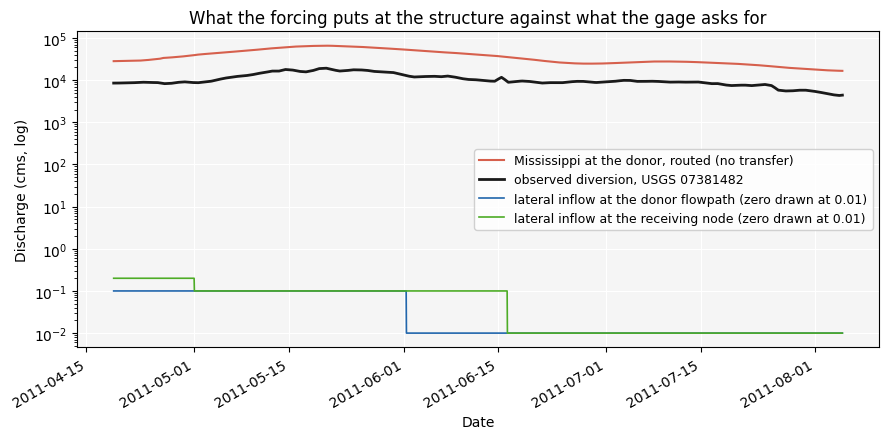

In [3]:
qlat = nu.qlat_series("channel_forcing", [DONOR, RECEIVER])
obs = nu.timeslice_series("usgs_da", "07381482")
donor_flow = nu.flow_at("output_no_diversion", DONOR)
window = slice(donor_flow.index[0], donor_flow.index[-1])
qlat, obs = qlat.loc[window], obs.loc[window]

table = pd.DataFrame({
    "lateral inflow at the donor flowpath (cms)": qlat[DONOR].describe()[["min", "50%", "max"]],
    "lateral inflow at the receiving node (cms)": qlat[RECEIVER].describe()[["min", "50%", "max"]],
    "routed Mississippi flow at the donor (cms)": donor_flow.describe()[["min", "50%", "max"]],
    "observed diversion, USGS 07381482 (cms)": obs.describe()[["min", "50%", "max"]],
}).T.round(2)
evidence["lateral inflow at the donor, max (cms)"] = float(qlat[DONOR].max())
evidence["observed diversion, median (cms)"] = float(obs.median())
display(table)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(donor_flow.index, donor_flow.values, label="Mississippi at the donor, routed (no transfer)", color=C_B, linewidth=1.5)
ax.semilogy(obs.index, obs.values, label="observed diversion, USGS 07381482", color=C_USGS, linewidth=2)
ax.semilogy(qlat.index, qlat[DONOR].clip(lower=1e-2).values, label="lateral inflow at the donor flowpath (zero drawn at 0.01)", color=C_A, linewidth=1.2)
ax.semilogy(qlat.index, qlat[RECEIVER].clip(lower=1e-2).values, label="lateral inflow at the receiving node (zero drawn at 0.01)", color=C_C, linewidth=1.2)
nu.style(ax, "What the forcing puts at the structure against what the gage asks for", "Discharge (cms, log)")
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(OUT_DIR / "diversion_inputs.png", dpi=150)

## 2. The observed series leaves the Mississippi and enters the Atchafalaya, every hour

The kernel routes each step with Muskingum-Cunge, then on copy-out subtracts the observation
from the donor segment's outflow and imposes it at the receiving node, where the observation
takes precedence over the routed flow; the amount removed is remembered so the next step's
state is not routed twice. At every written hour, then, the donor's flow with the transfer
off minus its flow with the transfer on should be the observation, and the receiving node's
flow should be the observation as well, since that creek carries almost nothing of its own
(its flow with the transfer off is printed). Both are compared with the observation as a
difference in cms. The two runs share everything but the transfer, so this shows the
implementation doing what it says; the rivers below, and the USGS records there, are the
physical check in section 3.

amount removed at the donor: within 0.006 cms of the observation over 2567 hours, none missing
amount added at the receiving node: within 0.000 cms of the observation
receiving node with the transfer off: at most 0.24 cms


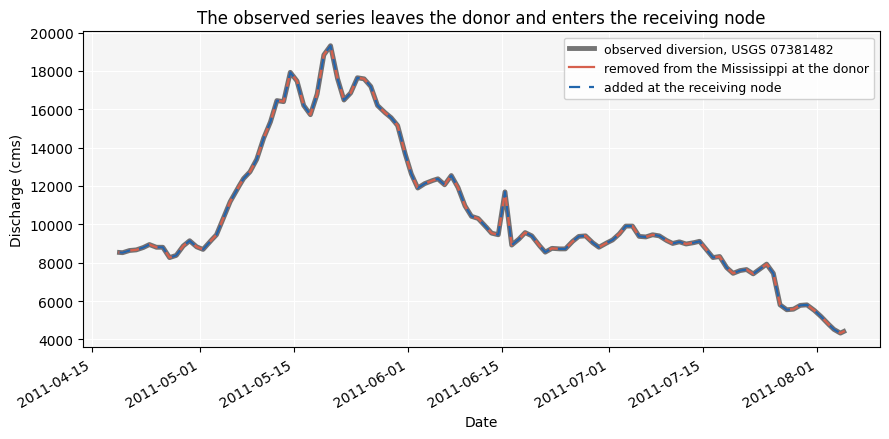

In [4]:
donor_with = nu.flow_at("output", DONOR)
receiver = nu.flow_at("output", RECEIVER)
removed = donor_flow - donor_with
settled = removed.index > removed.index[0] + pd.Timedelta(hours=24)
obs_h = obs.reindex(removed.index)

gap_removed = (removed - obs_h).abs()[settled]
gap_added = (receiver.reindex(removed.index) - obs_h).abs()[settled]
assert gap_removed.notna().all() and gap_added.notna().all(), "an hour without a comparison"
receiver_off = nu.flow_at("output_no_diversion", RECEIVER)
evidence["transfer: hours compared"] = int(settled.sum())
evidence["transfer: removed, max difference from the observation (cms)"] = float(gap_removed.max())
evidence["transfer: added, max difference from the observation (cms)"] = float(gap_added.max())
evidence["receiving node with the transfer off, max (cms)"] = float(receiver_off.max())
print(f"amount removed at the donor: within {gap_removed.max():.3f} cms of the observation over {settled.sum()} hours, none missing")
print(f"amount added at the receiving node: within {gap_added.max():.3f} cms of the observation")
print(f"receiving node with the transfer off: at most {receiver_off.max():.2f} cms")
assert gap_removed.max() < 1.0 and gap_added.max() < 1.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(obs_h.index, obs_h.values, label="observed diversion, USGS 07381482", color=C_USGS, linewidth=3.5, alpha=0.6)
ax.plot(removed.index, removed.values, label="removed from the Mississippi at the donor", color=C_B, linewidth=1.6)
ax.plot(receiver.index, receiver.values, label="added at the receiving node", color=C_A, linewidth=1.6, dashes=(5, 4))
nu.style(ax, "The observed series leaves the donor and enters the receiving node")
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(OUT_DIR / "diversion_transfer.png", dpi=150)

## 3. The rivers below the structure

What leaves the Mississippi reaches Baton Rouge and what enters the Atchafalaya reaches
Simmesport after their travel times, so the difference between the two runs at each gage
should be the diversion shifted and attenuated by routing, with the same volume over the run.
The lag is measured as the shift that best correlates each difference with the observation.
Upstream of the structure nothing changes: at Vicksburg the two runs coincide (checked below),
so in its figure the curves lie on top of each other. The four-gage comparison with USGS
follows; where runs coincide, one is drawn solid and the other dashed.

Baton Rouge loss: trails the observation by 50 h; volume over 2591 h is 1.007 of the observed diversion
Simmesport gain: trails the observation by 18 h; volume over 2591 h is 1.002 of the observed diversion
Vicksburg, upstream of the structure: the two runs differ by at most 0 cms


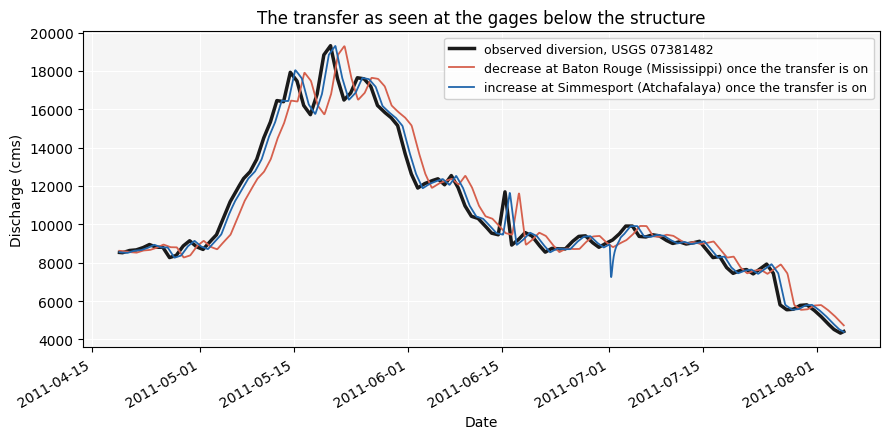

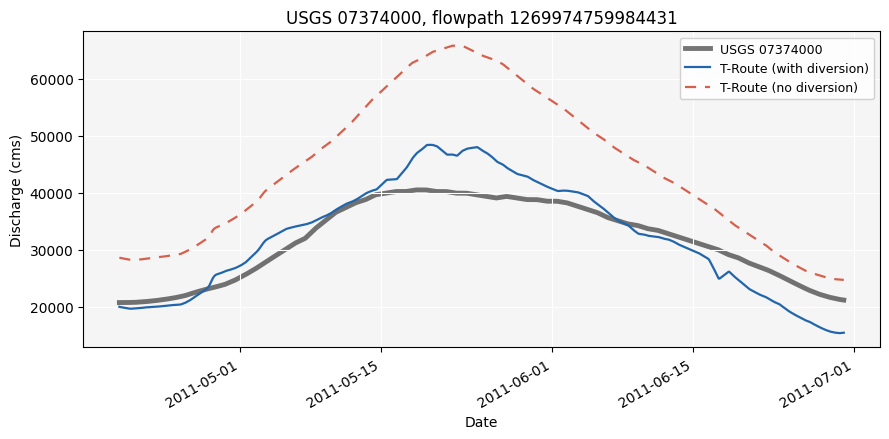

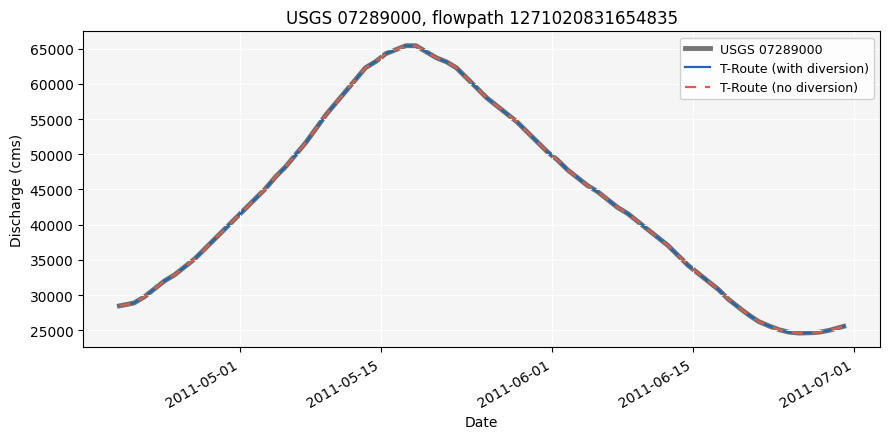

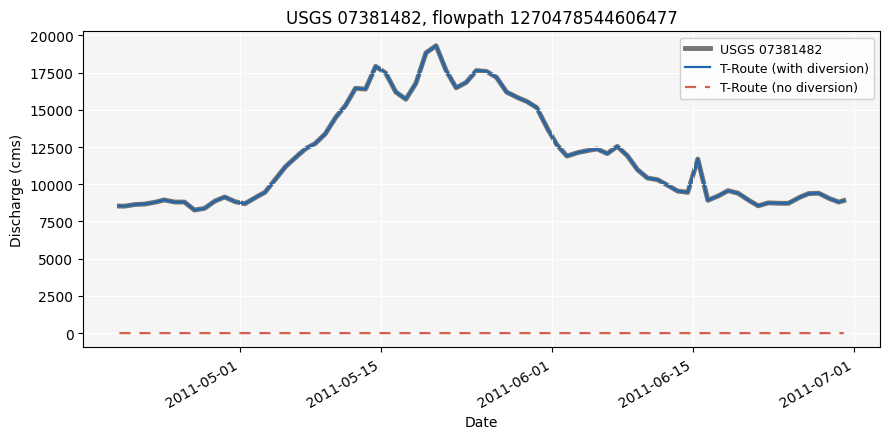

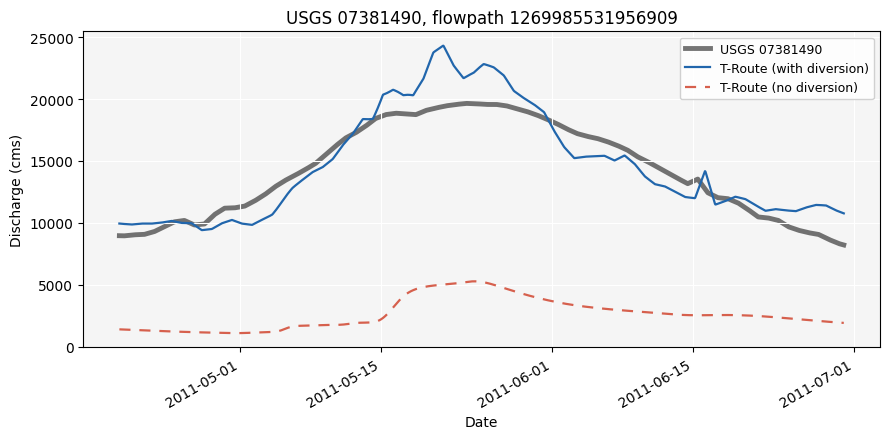

In [5]:
def diff_at(fp_id, sign):
    return sign * (nu.flow_at("output", fp_id) - nu.flow_at("output_no_diversion", fp_id))

lost_br = diff_at(BATON_ROUGE[1], -1)
gained_sim = diff_at(SIMMESPORT[1], +1)
hours = float((obs_h.index[-1] - obs_h.index[0]) / pd.Timedelta(hours=1))
for name, series in (("Baton Rouge loss", lost_br), ("Simmesport gain", gained_sim)):
    lag = nu.best_lag(series, obs_h)
    volume_ratio = float(series.sum() / obs_h.sum())
    evidence[f"{name}: lag (h)"] = lag
    evidence[f"{name} / observation, volume over the run"] = volume_ratio
    print(f"{name}: trails the observation by {lag} h; volume over {hours:.0f} h is {volume_ratio:.3f} of the observed diversion")
    assert abs(volume_ratio - 1.0) < 0.05

vicksburg_gap = float((nu.flow_at("output", VICKSBURG[1]) - nu.flow_at("output_no_diversion", VICKSBURG[1])).abs().max())
evidence["Vicksburg, max difference between the runs (cms)"] = vicksburg_gap
print(f"Vicksburg, upstream of the structure: the two runs differ by at most {vicksburg_gap:.3g} cms")
assert vicksburg_gap < 1.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(obs_h.index, obs_h.values, label="observed diversion, USGS 07381482", color=C_USGS, linewidth=2.5)
ax.plot(lost_br.index, lost_br.values, label="decrease at Baton Rouge (Mississippi) once the transfer is on", color=C_B, linewidth=1.3)
ax.plot(gained_sim.index, gained_sim.values, label="increase at Simmesport (Atchafalaya) once the transfer is on", color=C_A, linewidth=1.3)
nu.style(ax, "The transfer as seen at the gages below the structure")
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(OUT_DIR / "diversion_downstream.png", dpi=150)

nu.compare_runs(
    [("output", "T-Route (with diversion)"), ("output_no_diversion", "T-Route (no diversion)")],
    SITES, "_diversion", ref_data=REF_DATA, out_dir=OUT_DIR,
)

## 4. The last value persists after the record ends

In the persistence case the 07381482 record ends at 2011-05-31 while everything else runs on.
The last observation should then hold at both nodes for `diversion_persist_days` (45 here, so
the hold outlasts the reference period; the deployed configurations in
`test/troute_prod_configs` carry 11 to 32 days, and a value large enough never expires inside a
run), with no transition back to the simulated flow inside the horizon and no jump at the cut
beyond the record's own movement. At the horizon the hold ends at both nodes in the same hour:
the donor stops giving at once, and the receiving node, with nothing imposed on it, drains the
routed flow left in its creek within a few hours (measured below) and then carries nothing.

last observation before the cut: 14484 cms, held to 2011-07-15 00:00
hold error, donor 0.0000%, receiver 0.0000%
change across the cut (two hours) 55 cms; the record's median two-hour change before the cut 33 cms
at the horizon, hour before and after: removed (14484.0673828125, 0.0), receiver (14484.0673828125, 2896.8134765625)
the receiving node drains to under 1 percent of the held value within 2 h


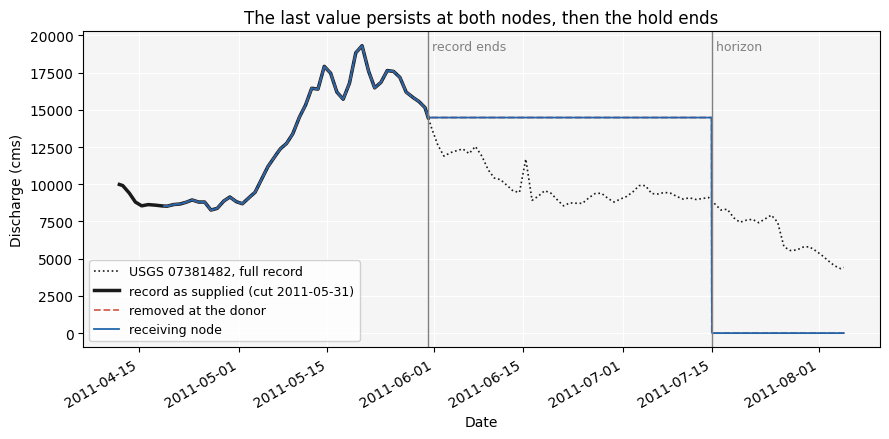

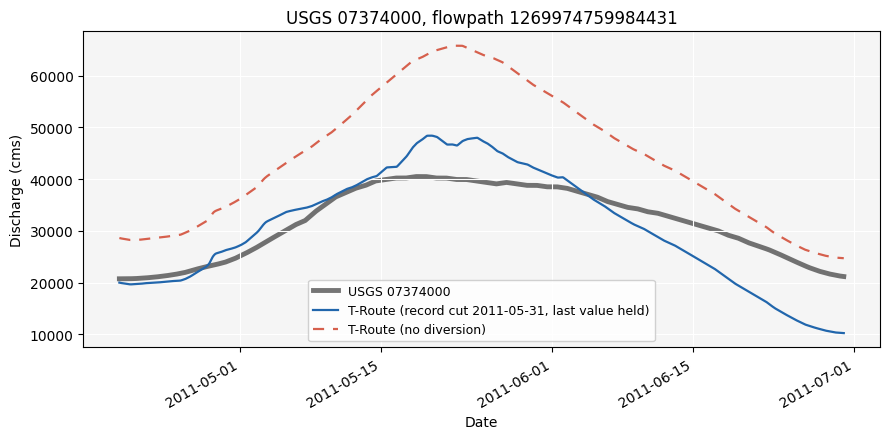

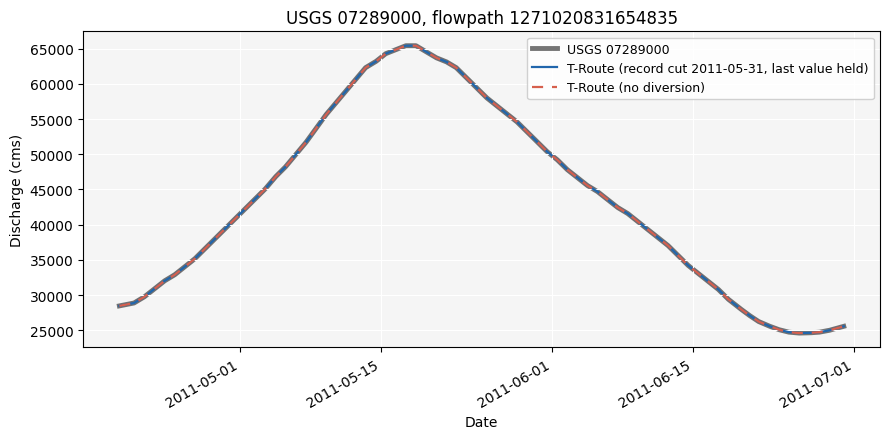

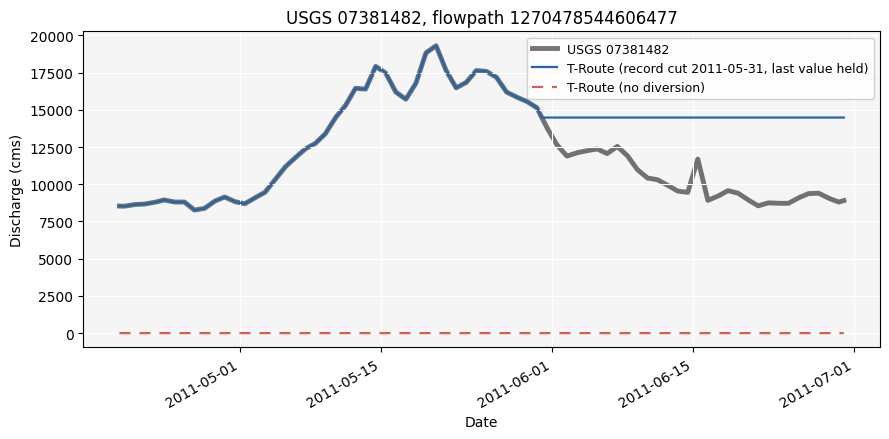

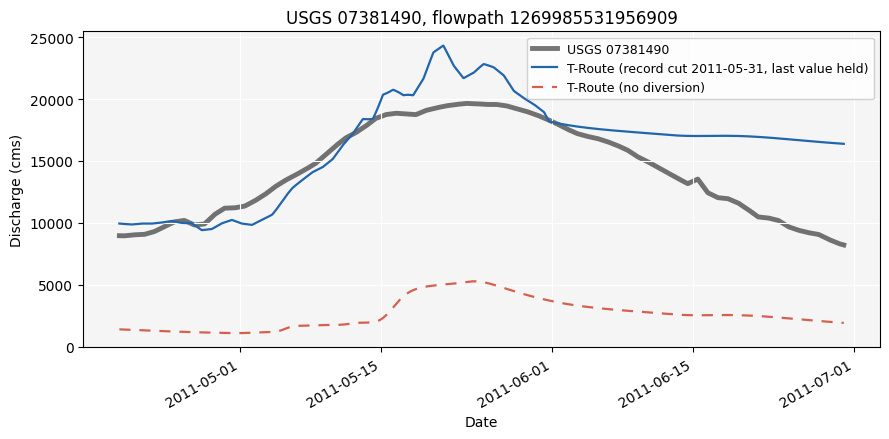

In [6]:
obs_cut = nu.timeslice_series("usgs_da_persist", "07381482")
last_obs = float(obs_cut[:OBS_CUT].dropna().iloc[-1])
horizon = OBS_CUT + pd.Timedelta(days=PERSIST_DAYS)
one_hour = pd.Timedelta(hours=1)
removed_p = nu.flow_at("output_no_diversion", DONOR) - nu.flow_at("output_persist", DONOR)
receiver_p = nu.flow_at("output_persist", RECEIVER)
held = (removed_p.index > OBS_CUT) & (removed_p.index < horizon)
after = removed_p.index > horizon + pd.Timedelta(hours=6)
median_step = float(obs_cut[:OBS_CUT].diff(2).abs().median())
drained = receiver_p[receiver_p.index > horizon] < 0.01 * last_obs

evidence["persistence: held value (cms)"] = last_obs
evidence["persistence: donor hold, max relative error"] = float(((removed_p[held] - last_obs).abs() / last_obs).max())
evidence["persistence: receiver hold, max relative error"] = float(((receiver_p[held] - last_obs).abs() / last_obs).max())
evidence["persistence: change across the cut (cms)"] = float(abs(removed_p[OBS_CUT + one_hour] - removed_p[OBS_CUT - one_hour]))
evidence["record's median two-hour change before the cut (cms)"] = median_step
evidence["at the horizon: removed, hour before and after (cms)"] = (float(removed_p[horizon - one_hour]), float(removed_p[horizon + one_hour]))
evidence["at the horizon: receiver, hour before and after (cms)"] = (float(receiver_p[horizon - one_hour]), float(receiver_p[horizon + one_hour]))
evidence["after the horizon, receiver (cms)"] = float(receiver_p[after].max())
evidence["after the horizon, removed (cms)"] = float(removed_p[after].abs().max())
evidence["receiver drains to under 1 percent of the held value within (h)"] = int(np.argmax(drained.to_numpy()) + 1)
print(f"last observation before the cut: {last_obs:.0f} cms, held to {horizon:%Y-%m-%d %H:%M}")
print(f"hold error, donor {100 * evidence['persistence: donor hold, max relative error']:.4f}%, receiver {100 * evidence['persistence: receiver hold, max relative error']:.4f}%")
print(f"change across the cut (two hours) {evidence['persistence: change across the cut (cms)']:.0f} cms; the record's median two-hour change before the cut {median_step:.0f} cms")
print(f"at the horizon, hour before and after: removed {evidence['at the horizon: removed, hour before and after (cms)']}, receiver {evidence['at the horizon: receiver, hour before and after (cms)']}")
print(f"the receiving node drains to under 1 percent of the held value within {evidence['receiver drains to under 1 percent of the held value within (h)']} h")
assert evidence["persistence: donor hold, max relative error"] < 1e-3 and evidence["persistence: receiver hold, max relative error"] < 1e-3
assert evidence["persistence: change across the cut (cms)"] < 4 * max(median_step, 1.0)
assert removed_p[horizon + one_hour] < 1.0, "the donor kept giving after the horizon"
assert evidence["receiver drains to under 1 percent of the held value within (h)"] <= 6
assert evidence["after the horizon, receiver (cms)"] < 1.0 and evidence["after the horizon, removed (cms)"] < 1.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(obs.index, obs.values, label="USGS 07381482, full record", color=C_USGS, linewidth=1.2, linestyle=":")
ax.plot(obs_cut.index, obs_cut.values, label="record as supplied (cut 2011-05-31)", color=C_USGS, linewidth=2.5)
ax.plot(removed_p.index, removed_p.values, label="removed at the donor", color=C_B, linewidth=1.3, linestyle="--")
ax.plot(receiver_p.index, receiver_p.values, label="receiving node", color=C_A, linewidth=1.3)
ax.axvline(OBS_CUT, color="gray", linewidth=1); ax.axvline(horizon, color="gray", linewidth=1)
ax.text(OBS_CUT, ax.get_ylim()[1] * 0.97, " record ends", va="top", fontsize=9, color="gray")
ax.text(horizon, ax.get_ylim()[1] * 0.97, " horizon", va="top", fontsize=9, color="gray")
nu.style(ax, "The last value persists at both nodes, then the hold ends")
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(OUT_DIR / "diversion_persistence.png", dpi=150)

nu.compare_runs(
    [("output_persist", "T-Route (record cut 2011-05-31, last value held)"), ("output_no_diversion", "T-Route (no diversion)")],
    SITES, "_persist", ref_data=REF_DATA, out_dir=OUT_DIR,
)

## 5. An observation larger than the flow available

One guard applies: the subtraction may not drive the Mississippi negative. When the
observation exceeds the routed flow at the donor, the donor should floor at zero, the run
should report it, and the Atchafalaya should still receive the full amount, so mass is not
conserved over those steps by design. To exercise the guard, the observation is scaled
fourfold from 2011-04-19 12:00 for two days, above the flow available at the donor.

diversion DA: donor reach 1271023511891281 was clamped to zero flow at 433 of 576 timestep(s) where a transfer was requested. Up to 4.47e+09 m3 was added to the receiving river without being removed here, because the observed diversion exceeded the routed flow. Mass is not conserved over those timesteps.
donor minimum 0.000 cms over the two days; at zero for 37 hours


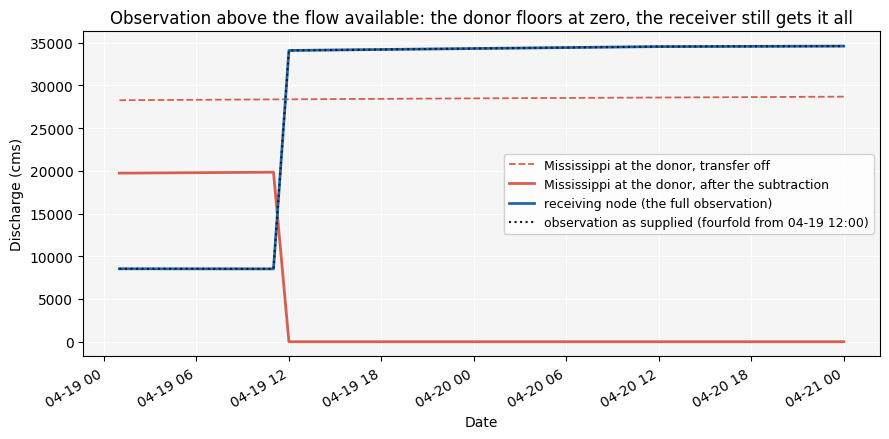

In [7]:
scaled = Path("usgs_da_overdraw")
scale_from = pd.Timestamp("2011-04-19 12:00")
nu.scale_observation(
    Path("usgs_da"), scaled, nu.Scaling("07381482", 4.0, scale_from),
    window=(pd.Timestamp("2011-04-17"), pd.Timestamp("2011-04-21 01:00")),
)
nu.variant_config(
    Path("config.yaml"), Path("config_overdraw.yaml"),
    nts=2 * 288, usgs_folder=scaled, output_dir=Path("output_overdraw"),
)
with nu.captured_warnings() as reported:
    nu.run("config_overdraw.yaml", LOG_FILE)
print("\n".join(reported) or "no diversion DA warning captured")

obs_x4 = nu.timeslice_series(scaled, "07381482")
donor_over = nu.flow_at("output_overdraw", DONOR)
receiver_over = nu.flow_at("output_overdraw", RECEIVER)
donor_off = donor_flow.reindex(donor_over.index)
removed_over = donor_off - donor_over
evidence["overdraw: donor minimum (cms)"] = float(donor_over.min())
evidence["overdraw: hours the donor sat at zero"] = int((donor_over.abs() < 1.0).sum())
evidence["overdraw: added minus removed, max (cms)"] = float((receiver_over - removed_over).max())
evidence["overdraw: volume added but not removed (m3)"] = float((receiver_over - removed_over).clip(lower=0).sum() * 3600)
print(f"donor minimum {donor_over.min():.3f} cms over the two days; at zero for {evidence['overdraw: hours the donor sat at zero']} hours")
assert donor_over.min() >= 0.0, "the Mississippi went negative"
assert evidence["overdraw: hours the donor sat at zero"] > 0, "the donor never floored at zero"
assert any("clamped to zero flow" in line for line in reported), "the clamp was not reported"
assert (receiver_over.reindex(obs_x4.index).dropna() - obs_x4.reindex(receiver_over.index).dropna()).abs().max() < 1.0

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(donor_off.index, donor_off.values, label="Mississippi at the donor, transfer off", color=C_B, linewidth=1.3, linestyle="--")
ax.plot(donor_over.index, donor_over.values, label="Mississippi at the donor, after the subtraction", color=C_B, linewidth=2)
ax.plot(receiver_over.index, receiver_over.values, label="receiving node (the full observation)", color=C_A, linewidth=2)
ax.plot(obs_x4.reindex(donor_over.index).index, obs_x4.reindex(donor_over.index).values, label="observation as supplied (fourfold from 04-19 12:00)", color=C_USGS, linewidth=1.5, linestyle=":")
nu.style(ax, "Observation above the flow available: the donor floors at zero, the receiver still gets it all")
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(OUT_DIR / "diversion_overdraw.png", dpi=150)

## 6. Baseline: the retrospective has no structure

NWM v3.0 does not model the structure; the medians below show its Atchafalaya at Simmesport
and its outflow channel against the observed records over the reference period. A state taken
from it lacks the transfer, which is why the runs above start from the spin-ups.

07374000: retrospective median 30322 cms, USGS median 31644 cms
07289000: retrospective median 30246 cms, USGS median 41543 cms
07381482: retrospective median 0 cms, USGS median 10364 cms
07381490: retrospective median 1199 cms, USGS median 13611 cms


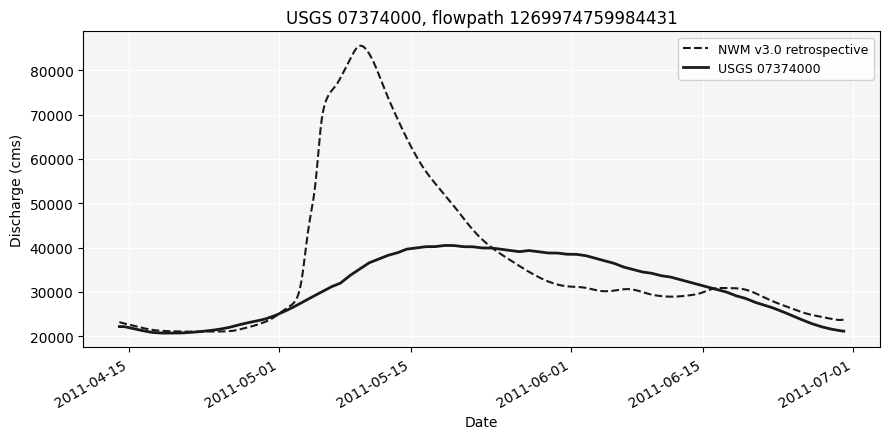

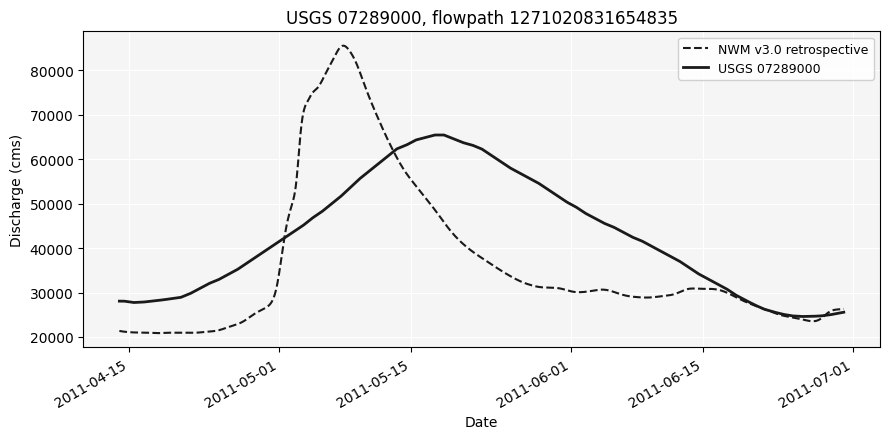

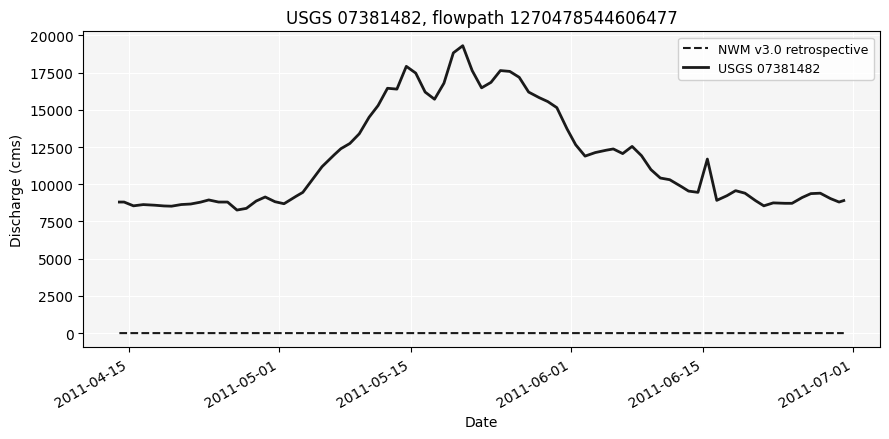

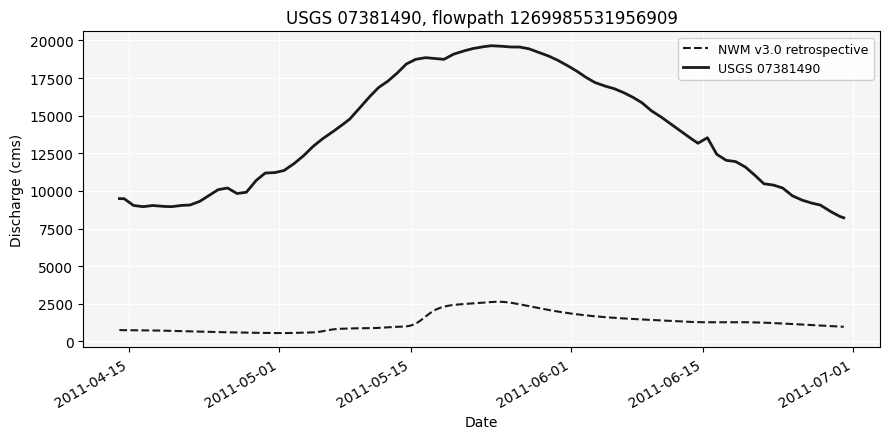

In [8]:
for site_no, (retro_median, usgs_median) in nu.compare_retro(SITES, ref_data=REF_DATA, out_dir=OUT_DIR).items():
    evidence[f"retrospective / USGS median at {site_no}"] = retro_median / usgs_median if usgs_median else float("nan")
    print(f"{site_no}: retrospective median {retro_median:.0f} cms, USGS median {usgs_median:.0f} cms")

## Summary of the computed evidence

In [9]:
summary = pd.Series(evidence, name="value").to_frame()
summary["value"] = summary["value"].map(lambda v: f"{v:.4g}" if isinstance(v, float) else v)
display(summary)

,value
"lateral inflow at the donor, max (cms)",0.1
"observed diversion, median (cms)",9339
transfer: hours compared,2567
"transfer: removed, max difference from the observation (cms)",0.005859
"transfer: added, max difference from the observation (cms)",0
"receiving node with the transfer off, max (cms)",0.24
Baton Rouge loss: lag (h),50
"Baton Rouge loss / observation, volume over the run",1.007
Simmesport gain: lag (h),18
"Simmesport gain / observation, volume over the run",1.002
